<a href="https://colab.research.google.com/github/SabinPopa1/PMP/blob/main/Tema%20HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cea mai prob secv de dificultati:  ['dificil', 'usor', 'dificil', 'usor', 'dificil', 'mediu', 'dificil', 'usor', 'dificil', 'usor', 'dificil', 'mediu']
Prob secv:  0.000000000021093750157851724336
Cea mai prob secv de dificultati:  ['dificil', 'usor', 'dificil', 'usor', 'dificil', 'mediu', 'dificil', 'usor', 'dificil', 'usor', 'dificil', 'mediu']
Prob secv:  0.000000000021093750000000004706


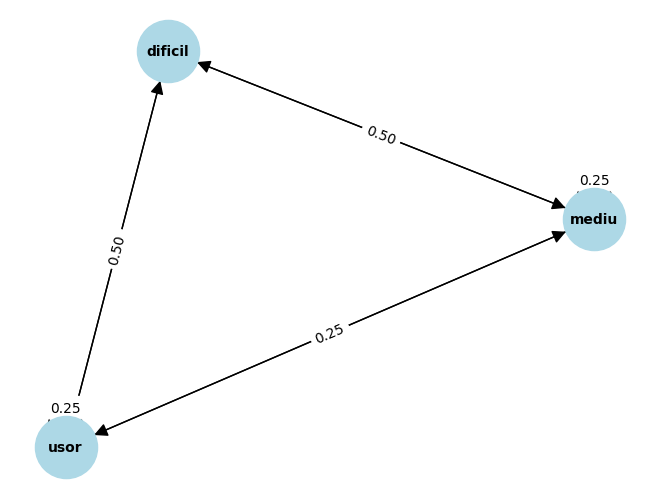

In [ ]:
import numpy as np
from decimal import Decimal, getcontext
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

getcontext().prec = 30

states = ["dificil", "mediu", "usor"]
observations = ["FB", "B", "S", "NS"]
n_states = len(states)

transition_matrix = np.array([
    [Decimal(0.0), Decimal(0.5), Decimal(0.5)],
    [Decimal(0.5), Decimal(0.25), Decimal(0.25)],
    [Decimal(0.5), Decimal(0.25), Decimal(0.25)]
], dtype=object)

emission_matrix = np.array([
    [Decimal(0.1), Decimal(0.2), Decimal(0.4), Decimal(0.3)],
    [Decimal(0.15), Decimal(0.25), Decimal(0.5), Decimal(0.1)],
    [Decimal(0.2), Decimal(0.3), Decimal(0.4), Decimal(0.1)]
], dtype=object)

initial_probabilities = np.array([Decimal(1) / Decimal(3)] * n_states, dtype=object)

observed_sequence = ["FB", "FB", "S", "B", "B", "S", "B", "B", "NS", "B", "B", "S"]
observed_indices = [observations.index(obs) for obs in observed_sequence]
def viterbi2(observed_indices, states, initial_probabilities, transition_matrix, emission_matrix):
    n_observations = len(observed_indices)
    n_states = len(states)

    dp = np.zeros((n_states, n_observations), dtype=float)
    path = np.zeros((n_states, n_observations), dtype=int)

    for s in range(n_states):
        dp[s, 0] = float(initial_probabilities[s]) * float(emission_matrix[s, observed_indices[0]])
        path[s, 0] = 0

    for t in range(1, n_observations):
        for j in range(n_states):
            prob_transitions = [dp[i, t - 1] * float(transition_matrix[i, j]) for i in range(n_states)]
            dp[j, t] = max(prob_transitions) * float(emission_matrix[j, observed_indices[t]])
            path[j, t] = np.argmax(prob_transitions)

    max_final_prob = max(dp[:, n_observations - 1])
    last_state = np.argmax(dp[:, n_observations - 1])

    most_probable_states = [last_state]
    for t in range(n_observations - 1, 0, -1):
        most_probable_states.insert(0, path[most_probable_states[0], t])

    most_probable_states_names = [states[state] for state in most_probable_states]

    return most_probable_states_names, max_final_prob

def viterbi(observed_indices, states, initial_probabilities, transition_matrix, emission_matrix):
    n_observations = len(observed_indices)
    n_states = len(states)

    epsilon = 1e-10
    log_transition_matrix = np.log(np.array(transition_matrix, dtype=float) + epsilon)
    log_emission_matrix = np.log(np.array(emission_matrix, dtype=float) + epsilon)
    log_initial_probabilities = np.log(np.array(initial_probabilities, dtype=float) + epsilon)

    dp = np.full((n_states, n_observations), -np.inf)
    path = np.zeros((n_states, n_observations), dtype=int)

    for s in range(n_states):
        dp[s, 0] = log_initial_probabilities[s] + log_emission_matrix[s, observed_indices[0]]
        path[s, 0] = 0

    for t in range(1, n_observations):
        for i in range(n_states):
            maxbuf = -np.inf
            for j in range(n_states):
                buf = log_transition_matrix[j, i] + dp[j, t - 1]
                if buf > maxbuf:
                    maxbuf = buf
            dp[i, t] = maxbuf + log_emission_matrix[i, observed_indices[t]]

    maxbuf = -np.inf
    max_pos = 0
    for j in range(n_states):
        buf = dp[j, n_observations - 1]
        if buf > maxbuf:
            maxbuf = buf
            max_pos = j

    logprob = maxbuf
    state_sequence = np.zeros(n_observations, dtype=int)
    state_sequence[n_observations - 1] = max_pos

    for t in range(n_observations - 2, -1, -1):
        maxbuf = -np.inf
        for j in range(n_states):
            buf = dp[j, t] + log_transition_matrix[j, state_sequence[t + 1]]
            if buf > maxbuf:
                maxbuf = buf
                max_pos = j
        state_sequence[t] = max_pos

    most_probable_states_names = [states[state] for state in state_sequence]

    return most_probable_states_names, np.exp(logprob)

most_probable_states, probability = viterbi(observed_indices, states, initial_probabilities, transition_matrix, emission_matrix)

most_probable_states2, probability2 = viterbi2(observed_indices, states, initial_probabilities, transition_matrix, emission_matrix)
print("Cea mai prob secv de dificultati: ", most_probable_states)
print("Prob secv: ", f"{probability:.30f}")

print("Cea mai prob secv de dificultati: ", most_probable_states2)
print("Prob secv: ", f"{probability2:.30f}")
state_counts = Counter(most_probable_states)
state_labels = list(state_counts.keys())
state_values = list(state_counts.values())

def plot_hmm_graph(states, transition_matrix):
    G = nx.DiGraph()
    for i, state in enumerate(states):
        G.add_node(state)
    for i, state_from in enumerate(states):
        for j, state_to in enumerate(states):
            prob = transition_matrix[i, j]
            if prob > 0:
                G.add_edge(state_from, state_to, weight=float(prob), label=f"{float(prob):.2f}")

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", font_size=10, font_weight="bold", arrowsize=20)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
    plt.show()

plot_hmm_graph(states, transition_matrix)